In [1]:
import json

import pandas as pd
import modules.distribution_plotting as dist

from pathlib import Path
import matplotlib.pyplot as plt

# Extraction Distribution

In [2]:
BRT_PRED_PATH = Path("../data/results/final/biored_test/biored_test_predictions.json")
CBC_PRED_PATH = Path("../data/results/final/contemporary/contemporary_predictions.json")

BRT_ENT_GT = Path("../data/processed/biored/br_test_entities.csv")
CBC_ENT_GT = Path("../data/processed/contemporary/cbc_ner_gt.csv")

BRT_REL_GT = Path("../data/processed/biored/br_test_entity_relations.csv")
CBC_REL_GT = Path("../data/processed/contemporary/cbc_re_gt.csv")

with open(BRT_PRED_PATH, "r") as f:
    brt_pred = json.load(f)

with open(CBC_PRED_PATH, "r") as f:
    cbc_pred = json.load(f)

In [3]:
brt_entities = pd.DataFrame(brt_pred["entities"])
cbc_entities = pd.DataFrame(cbc_pred["entities"])

brt_relations = pd.DataFrame(brt_pred["relations"])
cbc_relations = pd.DataFrame(cbc_pred["relations"])

brt_gt_entities = pd.read_csv(BRT_ENT_GT)
cbc_gt_entities = pd.read_csv(CBC_ENT_GT)

brt_gt_relations = pd.read_csv(BRT_REL_GT)
cbc_gt_relations = pd.read_csv(CBC_REL_GT)

downsampled_abstracts = pd.read_csv("../data/processed/contemporary/cbc_downsampled_abstracts.csv")
downsampled_pmids = set(downsampled_abstracts["pmid"])

cbc_entities_subset = cbc_entities[cbc_entities["pmid"].isin(downsampled_pmids)]
cbc_relations_subset = cbc_relations[cbc_relations["pmid"].isin(downsampled_pmids)]

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])


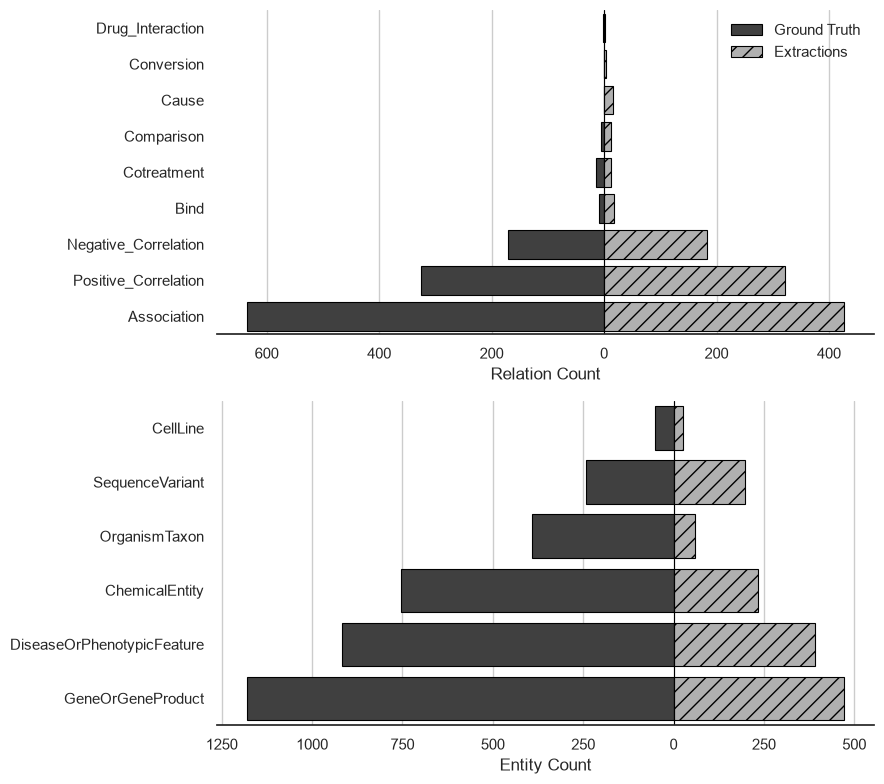

In [4]:
fig, axes = dist.plot_distribution_comparison(
    gt_entities=brt_gt_entities,
    pred_entities=brt_entities,
    gt_relations=brt_gt_relations,
    pred_relations=brt_relations,
)

fig.savefig("../img/final/extraction_distribution/brt_extraction_distribution.png")

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])


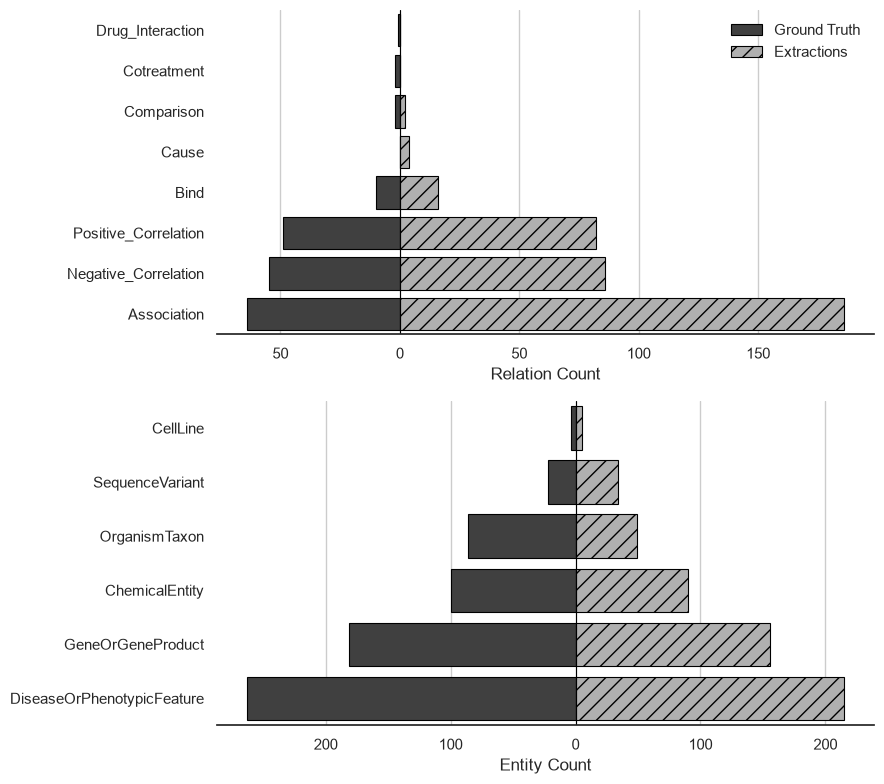

In [5]:
fig, axes = dist.plot_distribution_comparison(
    gt_entities=cbc_gt_entities,
    pred_entities=cbc_entities_subset,
    gt_relations=cbc_gt_relations,
    pred_relations=cbc_relations_subset,
)

fig.savefig("../img/final/extraction_distribution/cbc_extraction_distribution.png")

# Ground Truth Distribution

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])


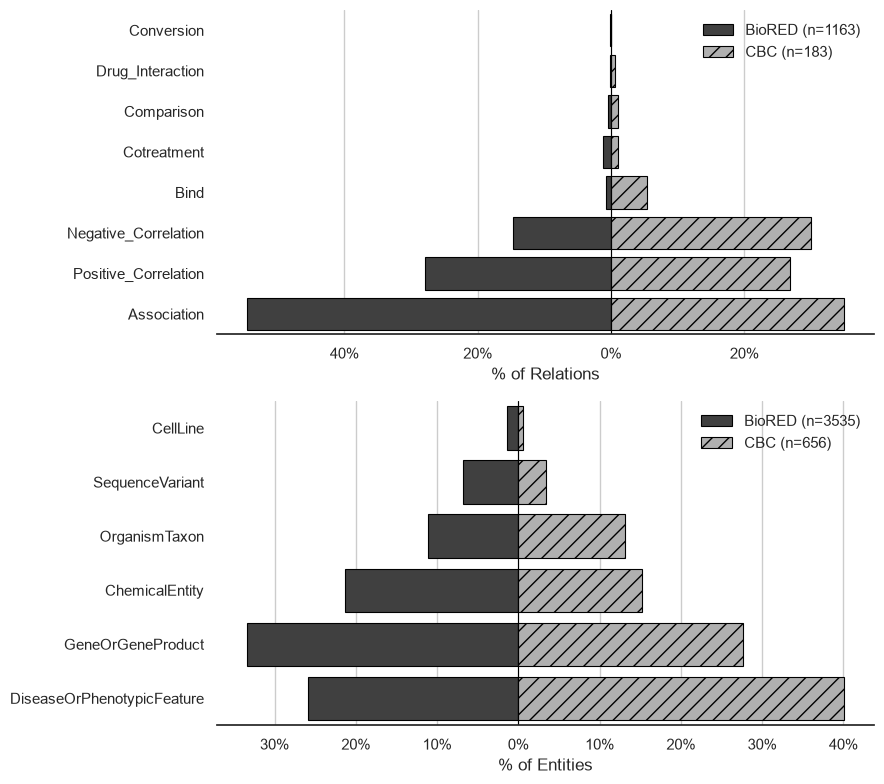

In [6]:
fig, axes = dist.plot_gt_distribution_comparison(
    biored_entities=brt_gt_entities,
    cbc_entities=cbc_gt_entities,
    biored_relations=brt_gt_relations,
    cbc_relations=cbc_gt_relations,
)

fig.savefig("../img/final/gt_distribution/all_gt_distribution.png")

In [7]:
len(brt_gt_entities["pmid"].unique())

100

,dataset,type,per_abstract
0,BioRED,Entities,35.350000
1,CBC,Entities,13.387755
2,BioRED,Relations,11.630000
3,CBC,Relations,5.545455


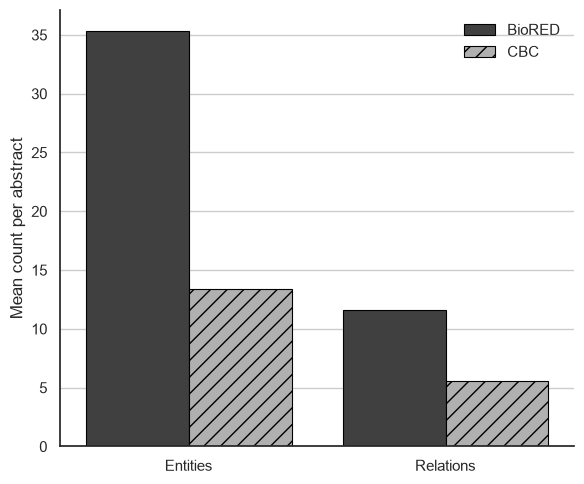

In [8]:
fig, ax = dist.plot_gt_ext_num(
    brt_gt_entities,
    brt_gt_relations,
    cbc_gt_entities,
    cbc_gt_relations
)

fig.savefig("../img/final/gt_distribution/all_ext_per_abstract.png")